# **EXPLORATORY DATA ANALYSIS**

In this notebook we explore the complete dataset to analyze its structure and data. 
It is not part of the Jenkins pipeline: its purpose is to give us a clear picture of the transformations we will apply in the Dask stage, 
such as dropping unused columns or filling missing counties. Each cleaning decision is tested and justified here, and then implemented in the Dask ingestion script.

In [ ]:
import glob
import os
import shutil
from getpass import getpass

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## **1. Environment setup**

We install [uv](https://docs.astral.sh/uv/), the package and project manager used by this repository. 
It is installed into `/usr/local/bin` so the following cells can call `uv` directly to sync the project's dependencies and run its scripts.

In [1]:
!curl -LsSf https://astral.sh/uv/install.sh | env UV_INSTALL_DIR=/usr/local/bin sh

downloading uv 0.12.22 x86_64-unknown-linux-gnu
installing to /usr/local/bin
  uv
  uvx
everything's installed!


## **2. Clone the repository**

Colab starts from an empty environment, so we clone the project repository to get its code and configuration: 
the `pyproject.toml` and `uv.lock` files that define the dependencies, and the scripts in `scripts/` that prepare the data. 
Then we move into the repository folder so the following commands run from the project root.

In [2]:
!git clone https://github.com/Loperaa-Juan/US-Wildfires-Big-Data.git

fatal: destination path 'US-Wildfires-Big-Data' already exists and is not an empty directory.


In [3]:
%cd US-Wildfires-Big-Data

/content/US-Wildfires-Big-Data


## **3. Install dependencies**

We synchronize the environment with the packages declared in the repository's `pyproject.toml`. 
`uv sync` creates a virtual environment and installs the exact versions pinned in `uv.lock`, so every run uses the same dependencies.

In [4]:
!uv sync

Resolved 18 packages in 1ms
Checked 16 packages in 0.53ms


Now, we need to configure our Kaggle credentials. 
The credentials are **never** written in the notebook: the cell below asks for the username and the API key when it runs (the key is typed in a hidden input box), and keeps them only in the runtime's environment variables, where `kagglehub` reads them. 
If `KAGGLE_USERNAME` and `KAGGLE_KEY` are already defined in the environment, the cell uses them and asks nothing. 
You can get both values from the `kaggle.json` file generated in Kaggle → Settings → API → Create New Token.

In [ ]:
# Ask for the Kaggle credentials only if they are not already in the environment
if not os.environ.get("KAGGLE_USERNAME"):
    os.environ["KAGGLE_USERNAME"] = input("Kaggle username: ")
if not os.environ.get("KAGGLE_KEY"):
    os.environ["KAGGLE_KEY"] = getpass("Kaggle API key: ")

## **4. Download the dataset**

In this step, we will load and transfom the dataset using the `download.py` and `transform.py` scripts. Once we have loaded and transformed the entire dataset, we can conti ue with the EDA. 

In [6]:
!uv run scripts/download.py

Using Colab cache for faster access to the '188-million-us-wildfires' dataset.
Path to dataset files: /kaggle/input/188-million-us-wildfires


In [7]:
# 1. Make sure the data/raw/ folder exists
os.makedirs("data/raw", exist_ok=True)

# 2. Find the .sqlite file in the path where Kaggle saved the download
kaggle_path = "/kaggle/input/188-million-us-wildfires"
sqlite_files = glob.glob(f"{kaggle_path}/**/*.sqlite", recursive=True)

if sqlite_files:
    src_file = sqlite_files[0]
    dst_file = os.path.join("data/raw", os.path.basename(src_file))

    # Copy the file to data/raw/
    shutil.copy(src_file, dst_file)
    print(f"✅ File successfully copied to: {dst_file}")
else:
    print("❌ No .sqlite file was found in the Kaggle path. Check the download.")

✅ File successfully copied to: data/raw/FPA_FOD_20170508.sqlite


In [8]:
!uv run scripts/transform.py

In [9]:
# Check that the CSV exists and read the first rows
df = pd.read_csv("data/processed/fires.csv")
print(f"✅ File successfully generated with {len(df):,} rows.")
df.head()

/tmp/ipykernel_13556/593151413.py:4: DtypeWarning: Columns (8,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/processed/fires.csv")


✅ File successfully generated with 1,880,465 rows.


,fod_id,fire_name,fire_year,stat_cause_descr,fire_size,fire_size_class,owner_descr,state,county,latitude,longitude,discovery_dt,cont_dt
0,1,FOUNTAIN,2005,Miscellaneous,0.10,A,USFS,CA,63.0,40.036944,-121.005833,2005-02-02 13:00:00,2005-02-02 17:30:00
1,2,PIGEON,2004,Lightning,0.25,A,USFS,CA,61.0,38.933056,-120.404444,2004-05-12 08:45:00,2004-05-12 15:30:00
2,3,SLACK,2004,Debris Burning,0.10,A,STATE OR PRIVATE,CA,17.0,38.984167,-120.735556,2004-05-31 19:21:00,2004-05-31 20:24:00
3,4,DEER,2004,Lightning,0.10,A,USFS,CA,3.0,38.559167,-119.913333,2004-06-28 16:00:00,2004-07-03 14:00:00
4,5,STEVENOT,2004,Lightning,0.10,A,USFS,CA,3.0,38.559167,-119.933056,2004-06-28 16:00:00,2004-07-03 12:00:00


## **5. Exploratory analysis**

In [10]:
# Load the data avoiding mixed-dtype warnings
df = pd.read_csv("data/processed/fires.csv", low_memory=False)

# General overview of the dataset
print("--- Dataset Information ---")
df.info()

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1880465 entries, 0 to 1880464
Data columns (total 13 columns):
 #   Column            Dtype  
---  ------            -----  
 0   fod_id            int64  
 1   fire_name         object 
 2   fire_year         int64  
 3   stat_cause_descr  object 
 4   fire_size         float64
 5   fire_size_class   object 
 6   owner_descr       object 
 7   state             object 
 8   county            object 
 9   latitude          float64
 10  longitude         float64
 11  discovery_dt      object 
 12  cont_dt           object 
dtypes: float64(3), int64(2), object(8)
memory usage: 186.5+ MB


In [11]:
# Keep only text columns (object / string)
text_cols = df.select_dtypes(include=['object']).columns

print("--- DETAILED REPORT: NULLS VS. EMPTY ---")
for col in text_cols:
    nulos = df[col].isnull().sum()
    vacio_exacto = (df[col] == "").sum()
    solo_espacios = (df[col].astype(str).str.strip() == "").sum() - nulos - vacio_exacto

    print(f"Column '{col}':")
    print(f"  - Nulls (NaN): {nulos:,}")
    print(f"  - Empty (\"\"): {vacio_exacto:,}")
    print(f"  - Whitespace only (\" \"): {solo_espacios:,}")
    print("-" * 40)

--- DETAILED REPORT: NULLS VS. EMPTY ---
Column 'fire_name':
  - Nulls (NaN): 960,479
  - Empty (""): 0
  - Whitespace only (" "): -960,479
----------------------------------------
Column 'stat_cause_descr':
  - Nulls (NaN): 0
  - Empty (""): 0
  - Whitespace only (" "): 0
----------------------------------------
Column 'fire_size_class':
  - Nulls (NaN): 0
  - Empty (""): 0
  - Whitespace only (" "): 0
----------------------------------------
Column 'owner_descr':
  - Nulls (NaN): 0
  - Empty (""): 0
  - Whitespace only (" "): 0
----------------------------------------
Column 'state':
  - Nulls (NaN): 0
  - Empty (""): 0
  - Whitespace only (" "): 0
----------------------------------------
Column 'county':
  - Nulls (NaN): 678,148
  - Empty (""): 0
  - Whitespace only (" "): -678,148
----------------------------------------
Column 'discovery_dt':
  - Nulls (NaN): 0
  - Empty (""): 0
  - Whitespace only (" "): 0
----------------------------------------
Column 'cont_dt':
  - Nulls (NaN)

In [12]:
print("\n--- Null Value Count ---")
print(df.isnull().sum())


--- Null Value Count ---
fod_id                   0
fire_name           960479
fire_year                0
stat_cause_descr         0
fire_size                0
fire_size_class          0
owner_descr              0
state                    0
county              678148
latitude                 0
longitude                0
discovery_dt             0
cont_dt             891531
dtype: int64


In [13]:
print("\n--- Statistical Summary of Numeric Variables ---")
display(df.describe())


--- Statistical Summary of Numeric Variables ---


,fod_id,fire_year,fire_size,latitude,longitude
count,1.880465e+06,1.880465e+06,1.880465e+06,1.880465e+06,1.880465e+06
mean,5.484020e+07,2.003710e+03,7.452016e+01,3.678121e+01,-9.570494e+01
std,1.011963e+08,6.663099e+00,2.497598e+03,6.139031e+00,1.671694e+01
min,1.000000e+00,1.992000e+03,1.000000e-05,1.793972e+01,-1.788026e+02
25%,5.055000e+05,1.998000e+03,1.000000e-01,3.281860e+01,-1.103635e+02
50%,1.067761e+06,2.004000e+03,1.000000e+00,3.545250e+01,-9.204304e+01
75%,1.910639e+07,2.009000e+03,3.300000e+00,4.082720e+01,-8.229760e+01
max,3.003484e+08,2.015000e+03,6.069450e+05,7.033060e+01,-6.525694e+01


Let's see the distribution of the wildfires in a map. This is a technique that helps us to identify outliers (coordinates that don't belong to U.S.A)

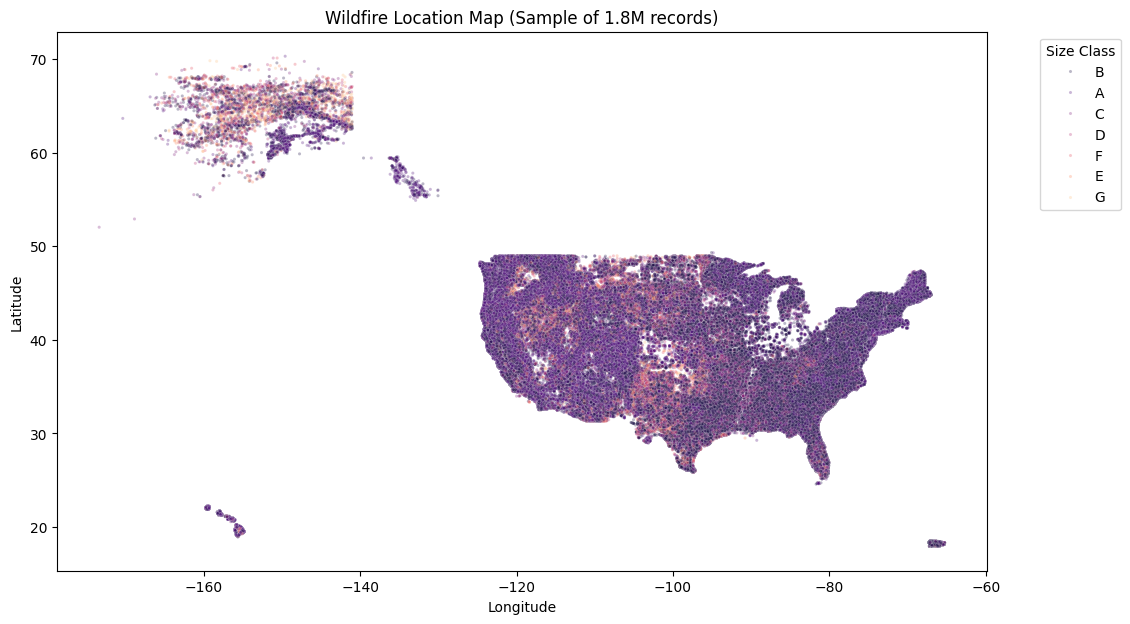

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df.sample(n=1800000, random_state=42), # Representative sample to keep plotting fast
    x='longitude',
    y='latitude',
    hue='fire_size_class',
    alpha=0.3,
    s=5,
    palette='magma'
)
plt.title('Wildfire Location Map (Sample of 1.8M records)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Size Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### **County column**

In [15]:
print("Top 10 counties (excluding nulls):")
print(df['county'].value_counts(dropna=True).head(10))

Top 10 counties (excluding nulls):
county
5             7576
Lincoln       7405
SUFFOLK       7373
Polk          6955
Washington    6916
Cherokee      6796
Oahu          6777
Marion        6657
Jackson       6305
Lee           5914
Name: count, dtype: int64


In [16]:
# See which states the records with county == '5' (or 5) come from
df[df['county'].astype(str) == '5']['state'].value_counts()

,count
state,
AZ,5943
OR,950
SC,99
NV,92
ID,87
WI,72
WY,64
CA,59
UT,59


In [17]:
# 1. Load the US COUNTIES vector map
url_condados = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_20m.zip"
mapa_condados = gpd.read_file(url_condados)

# 2. Build a GeoDataFrame from the wildfire coordinates
# The dataset's coordinates are in NAD83 (EPSG:4269)
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs="EPSG:4269",
)

# 3. Reproject the data's GeoDataFrame to the county map's CRS
gdf = gdf.to_crs(mapa_condados.crs)

# 4. Spatial join with the county map ('NAME' holds the county name)
gdf_condados = gpd.sjoin(gdf, mapa_condados[['NAME', 'geometry']], how='left', predicate='within')

# 5. Store the result in a new column (or overwrite 'county')
df['county_calculado'] = gdf_condados['NAME']

# Show the resulting data
print(df[['state', 'county', 'county_calculado']].head(10))

  state county county_calculado
0    CA     63           Plumas
1    CA     61        El Dorado
2    CA     17        El Dorado
3    CA      3           Alpine
4    CA      3           Alpine
5    CA      5           Amador
6    CA     17        El Dorado
7    CA    NaN           Shasta
8    CA    NaN         Siskiyou
9    CA      5           Amador


In [18]:
# Overwrite the 'county' column with the real name
df['county'] = df['county_calculado']
df = df.drop(columns=['county_calculado'])

# Drop any leftover column created by the spatial join, if present
if 'index_right' in df.columns:
    df = df.drop(columns=['index_right'])

# Check how many nulls remain in 'county'
print("Remaining null values in county:", df['county'].isnull().sum())
print("\nTop 10 cleaned counties:")
print(df['county'].value_counts().head(10))

Remaining null values in county: 1940

Top 10 cleaned counties:
county
Riverside     19221
Lincoln       17780
Coconino      15681
Jackson       14456
Washington    14306
Jefferson     12323
Marion        12254
Cherokee      11667
Lake          10468
Beltrami      10167
Name: count, dtype: int64


In [19]:
# Configure pandas to show every row without truncation
pd.set_option('display.max_rows', None)
print(df['county'].value_counts(dropna=False))

# Restore pandas' default limit if you need it later
pd.reset_option('display.max_rows')

county
Riverside                19221
Lincoln                  17780
Coconino                 15681
Jackson                  14456
Washington               14306
Jefferson                12323
Marion                   12254
Cherokee                 11667
Lake                     10468
Beltrami                 10167
Monroe                   10047
Grant                     9821
Polk                      9774
Lee                       9569
San Diego                 9562
Wayne                     9141
Gila                      9037
Humboldt                  8841
San Bernardino            8642
Tulare                    8470
Douglas                   8418
Fresno                    8373
Union                     8113
Merced                    7737
Suffolk                   7731
Richmond                  7425
Jasper                    7337
Idaho                     7299
Oglala Lakota             7060
Orange                    6962
Maricopa                  6922
Franklin                  6916
C

### **Dropping columns and remaining nulls**

We drop two columns that do not add value to the analysis: 
- `fire_name`: it only describes the name given to each incident, so it is not useful for the spatial or temporal analysis. 
- `cont_dt`: the containment date has 891,531 null values, more than 800k rows without information. 

After filling the `county` column with the spatial join, its null values went from 678,148 to only 1,940. 
Those remaining 1,940 records are deleted because they are a negligible share of the dataset.

In [20]:
df = df.drop(columns=['fire_name', 'cont_dt'])
df = df.dropna(subset=['county'])

In [21]:
df.isnull().sum()

,0
fod_id,0
fire_year,0
stat_cause_descr,0
fire_size,0
fire_size_class,0
owner_descr,0
state,0
county,0
latitude,0
longitude,0
